In [259]:
import pandas as pd
import pickle
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from scipy.stats import chi2
import textwrap

In [260]:
DISEASE = input("Disease: ")
DISEASE_FOLDER = f"../output/{DISEASE}/"
RESULT_FOLDER = DISEASE_FOLDER + "leiden_results"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"

# Comm DGIDB genes count

In [261]:
def DGIDB_count(c,DGIDB_genes_ncbi):
    return set(c) & set(DGIDB_genes_ncbi)

In [262]:
with open(f"{RESULT_FOLDER}/result_communities_ncbi_selected.pkl", "rb") as f:
    communities_ncbi_selected = pickle.load(f)
with open(f"{RESULT_FOLDER}/result_communities_ncbi.pkl", "rb") as f:
    communities_ncbi = pickle.load(f)
with open(DGIDB_DIRECTORY + f"gene_to_index.json", "r") as file:
    DGIDB_gene_to_index = json.load(file)
DGIDB_genes = set(DGIDB_gene_to_index.keys())

In [263]:
comm_dgidb_gene_count = {}
for i in range(len(communities_ncbi_selected)):
    dgidb_genes_set = DGIDB_count(communities_ncbi[i],DGIDB_genes)
    print(i,len(dgidb_genes_set), dgidb_genes_set)
    print(len(communities_ncbi[i]))
    comm_dgidb_gene_count[i] = len(dgidb_genes_set)
    
with open(f"../output/{DISEASE}/comm_dgidb_gene_count.json","w") as f:
    json.dump(comm_dgidb_gene_count,f)    

0 2 {'236', '170679'}
3184
1 83 {'53353', '154', '2563', '26298', '6332', '107', '2675', '23040', '5565', '2564', '1002', '2567', '4915', '7916', '57476', '4049', '5020', '2784', '1407', '22', '64816', '2558', '6334', '3727', '2565', '7365', '259232', '1993', '7905', '360158', '6571', '80862', '55534', '2952', '4295', '10369', '2569', '7504', '2556', '12', '51252', '7252', '116987', '706', '11201', '28755', '885', '11280', '3127', '5999', '6750', '9970', '5325', '13', '55879', '6326', '5799', '2559', '339896', '2570', '23', '4835', '108', '2796', '6328', '10', '3125', '79529', '64067', '22854', '170680', '23216', '6728', '10951', '5563', '632', '926', '128553', '3699', '2557', '2568', '25970', '200959'}
2950
2 0 set()
2558
3 0 set()
2412
4 1 {'54579'}
2319
5 1 {'2895'}
2159
6 6 {'345222', '119678', '283446', '283635', '100130889', '119679'}
2088
7 0 set()
2078
8 6 {'3176', '3760', '50852', '2194', '265', '24'}
1277
9 23 {'2913', '2671', '2641', '1133', '319100', '267012', '693167', '92

# important terms processing

In [264]:
with open(f"{RESULT_FOLDER}/result_communities_selected.pkl", "rb") as f:
    communities_selected = pickle.load(f)

In [265]:
important_terms = pd.read_csv(DISEASE_FOLDER + "important_terms.csv")

In [266]:
important_terms = important_terms.sort_values(
    by=["Community Index", "Adjusted P-value"],
    ascending=[True, True]
).reset_index(drop=True)

In [267]:
important_terms

,Community Index,Community Size,Term,Overlap,Adjusted P-value,Category,Gene_set,P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Overlap (value)
0,0,1124,Mitochondrial Translation Termination R-HSA-54...,20/82,1.970428e-06,['Metabolism of proteins'],Reactome_2022,1.847276e-08,0.0,0.0,5.497312,9.789046e+01,MRPS35;MRPS25;MRPS11;MRPS23;MRPL38;MRPL49;MRPL...,0.243902
1,0,1124,Mitochondrial Translation Initiation R-HSA-536...,20/82,1.970428e-06,['Metabolism of proteins'],Reactome_2022,1.847276e-08,0.0,0.0,5.497312,9.789046e+01,MRPS35;MRPS25;MRPS11;MRPS23;MRPL38;MRPL49;MRPL...,0.243902
2,0,1124,Mitochondrial Translation Elongation R-HSA-538...,20/82,1.970428e-06,['Metabolism of proteins'],Reactome_2022,1.847276e-08,0.0,0.0,5.497312,9.789046e+01,MRPS35;MRPS25;MRPS11;MRPS23;MRPL38;MRPL49;MRPL...,0.243902
3,0,1124,Mitochondrial Translation R-HSA-5368287,20/88,5.301778e-06,['Metabolism of proteins'],Reactome_2022,6.627222e-08,0.0,0.0,5.010656,8.282362e+01,MRPS35;MRPS25;MRPS11;MRPS23;MRPL38;MRPL49;MRPL...,0.227273
4,0,1124,Mitochondrial Translation (GO:0032543),21/98,5.786204e-05,['cellular process'],GO_Biological_Process_2023,9.265339e-08,0.0,0.0,4.648232,7.527533e+01,MRPS25;MRPS11;MRPS23;MRPL16;MRPL27;MRPL38;MRPL...,0.214286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,9,383,Sensory Perception R-HSA-9709957,360/616,0.000000e+00,['Sensory Perception'],Reactome_2022,0.000000e+00,0.0,0.0,1183.756793,inf,OR7G2;OR7G1;OR8I2;OR9K2;OR11H2;OR11H1;OR11H4;O...,0.584416
857,9,383,Sensory Perception Of Smell (GO:0007608),187/230,2.066115e-297,['multicellular organismal process'],GO_Biological_Process_2023,5.903185e-299,0.0,0.0,434.306834,2.982374e+05,OR8I2;OR1C1;OR2M7;OR2M5;OR2M4;OR2M3;OR2M2;OR2T...,0.813043
858,9,383,Detection Of Chemical Stimulus Involved In Sen...,119/141,2.241336e-187,['response to stimulus'],GO_Biological_Process_2023,1.280764e-188,0.0,0.0,401.481577,1.736964e+05,OR2M7;OR2M5;OR2M4;OR2M3;OR2M2;OR2T12;OR2T10;OR...,0.843972
859,9,383,Detection Of Chemical Stimulus Involved In Sen...,118/139,1.506544e-186,['response to stimulus'],GO_Biological_Process_2023,1.291324e-187,0.0,0.0,415.512668,1.788066e+05,OR2M7;OR2M5;OR2M4;OR2M3;OR2M2;OR2T12;OR2T10;OR...,0.848921


# Community Category df

In [268]:
df = important_terms

# ---------------------------------------------------
# 1. Parse Category column (stringified list) -> list
# ---------------------------------------------------
df["Category"] = df["Category"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# ---------------------------------------------------
# 2. Explode: one category per row
# ---------------------------------------------------
df_exp = df.explode("Category").reset_index(drop=True)

# ---------------------------------------------------
# 3. Parse Overlap "a/b" into numerator and denominator
# ---------------------------------------------------
def parse_overlap(s):
    try:
        a, b = s.split("/")
        return int(a), int(b)
    except Exception:
        return 0, 0

overlap_nums = []
overlap_dens = []

for s in df_exp["Overlap"]:
    a, b = parse_overlap(s)
    overlap_nums.append(a)
    overlap_dens.append(b)

df_exp["Overlap_num"] = overlap_nums
df_exp["Overlap_den"] = overlap_dens

# ---------------------------------------------------
# 4. Total number of terms per community
# ---------------------------------------------------
total_terms = (
    df_exp.groupby("Community Index")["Term"]
          .nunique()
)

# ---------------------------------------------------
# 5. Aggregate per (Community Index, Category)
#    - count = # of distinct terms
#    - Gross Overlap = (sum a_i) / (sum b_i)
# ---------------------------------------------------
# ---------------------------------------------------
# 5. Aggregate per (Community Index, Category)
#    - count = # of distinct terms
#    - Gross Overlap = (sum a_i) / (sum b_i)
#    - fisher_p = Fisher-combined p-value over terms in that category
# ---------------------------------------------------
def fisher_method(pvals):
    p = pd.Series(pvals).dropna().astype(float)
    if len(p) == 0:
        return np.nan

    # avoid log(0)
    p = p.clip(lower=1e-300)

    stat = -2.0 * np.sum(np.log(p))
    df = 2 * len(p)
    return float(chi2.sf(stat, df))

agg = (
    df_exp.groupby(["Community Index", "Category"])
    .agg(
        count=("Term", "nunique"),
        sum_a=("Overlap_num", "sum"),
        sum_b=("Overlap_den", "sum"),
        fisher_p=("Adjusted P-value", fisher_method),  # <-- change column name if needed
    )
    .reset_index()
)

agg["Gross Overlap"] = agg["sum_a"] / agg["sum_b"]

# ---------------------------------------------------
# 6. Add total_terms_in_comm and frac_of_comm
# ---------------------------------------------------
agg["total_terms_in_comm"] = agg["Community Index"].map(total_terms)
agg["frac_of_comm"] = agg["count"] / agg["total_terms_in_comm"]

# ---------------------------------------------------
# 7. Final output df
# ---------------------------------------------------
community_categories = agg[[
    "Community Index",
    "Category",
    "count",
    "Gross Overlap",
    "fisher_p",
    "total_terms_in_comm",
    "frac_of_comm",
]]


community_categories = community_categories.sort_values(
    by=["Community Index", "count"],
    ascending=[True, False]
).reset_index(drop=True)

community_categories


,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm
0,0,Metabolism of proteins,4,0.239521,9.826001e-19,6,0.666667
1,0,cellular process,2,0.213930,6.868420e-08,6,0.333333
2,1,Metabolism of proteins,18,0.273230,5.730019e-161,70,0.257143
3,1,Signal Transduction,9,0.148764,1.947124e-39,70,0.128571
4,1,Metabolism of RNA,6,0.201809,1.789841e-66,70,0.085714
...,...,...,...,...,...,...,...
84,9,Sensory Perception,3,0.763121,0.000000e+00,9,0.333333
85,9,multicellular organismal process,2,0.785294,0.000000e+00,9,0.222222
86,9,response to stimulus,2,0.846429,0.000000e+00,9,0.222222
87,9,Sensory system,1,0.834091,1.000000e-300,9,0.111111


In [269]:
community_categories["fisher_score"] = -np.log10(
    community_categories["fisher_p"].clip(lower=1e-300)
)

mn = community_categories["fisher_score"].min()
mx = community_categories["fisher_score"].max()

community_categories["fisher_norm"] = (community_categories["fisher_score"] - mn) / (mx - mn)

def safe_z(x):
    mu = x.mean()
    sd = x.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return pd.Series(0.0, index=x.index)   # or return x*0
    return (x - mu) / sd

community_categories["fisher_z"] = (
    community_categories
    .groupby("Community Index")["fisher_score"]
    .transform(safe_z)
)




In [270]:
community_categories

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_norm,fisher_z
0,0,Metabolism of proteins,4,0.239521,9.826001e-19,6,0.666667,18.007623,0.050389,1.000000
1,0,cellular process,2,0.213930,6.868420e-08,6,0.333333,7.163143,0.013870,-1.000000
2,1,Metabolism of proteins,18,0.273230,5.730019e-161,70,0.257143,160.241844,0.529363,3.448410
3,1,Signal Transduction,9,0.148764,1.947124e-39,70,0.128571,38.710606,0.120106,0.143691
4,1,Metabolism of RNA,6,0.201809,1.789841e-66,70,0.085714,65.747186,0.211152,0.878879
...,...,...,...,...,...,...,...,...,...,...
84,9,Sensory Perception,3,0.763121,0.000000e+00,9,0.333333,300.000000,1.000000,0.000000
85,9,multicellular organismal process,2,0.785294,0.000000e+00,9,0.222222,300.000000,1.000000,0.000000
86,9,response to stimulus,2,0.846429,0.000000e+00,9,0.222222,300.000000,1.000000,0.000000
87,9,Sensory system,1,0.834091,1.000000e-300,9,0.111111,300.000000,1.000000,0.000000


## filtering top 5 categories

In [271]:
# community_categories_filtered = (
#     community_categories.sort_values(["Community Index", "count"], ascending=[True, False])
#           .groupby("Community Index")
#           .head(5)
#           .reset_index(drop=True)
# )

In [272]:
# community_categories_filtered

In [273]:
# from reportlab.lib.pagesizes import letter, landscape
# from reportlab.platypus import SimpleDocTemplate, Table, TableStyle
# from reportlab.lib import colors

# def df_to_pdf(df, filename="output.pdf"):
#     pdf = SimpleDocTemplate(
#         filename,
#         pagesize=landscape(letter)
#     )

#     # Convert DF to 2D list
#     data = [df.columns.tolist()] + df.values.tolist()

#     # Create table
#     table = Table(data)

#     # Styling
#     style = TableStyle([
#         ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
#         ("TEXTCOLOR", (0,0), (-1,0), colors.black),
#         ("ALIGN", (0,0), (-1,-1), "CENTER"),
#         ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
#         ("FONTSIZE", (0,0), (-1,-1), 8),
#         ("BOTTOMPADDING", (0,0), (-1,0), 8),
#         ("GRID", (0,0), (-1,-1), 0.25, colors.black),
#     ])
#     table.setStyle(style)

#     elements = [table]
#     pdf.build(elements)
#     print(f"PDF saved to {filename}")


## output to pdf

In [274]:
# community_categories_filtered

In [275]:
# df_to_pdf(community_categories_filtered, f"../../Graphs/{DISEASE}/community_categories_filtered.pdf")

# Community Count Dict

In [276]:
category_count_by_comm = {}

for _, row in community_categories.iterrows():
    comm = row["Community Index"]
    cat = row["Category"]
    count = row["count"]
    gross = row["Gross Overlap"]

    if comm not in category_count_by_comm:
        category_count_by_comm[comm] = {}

    # insertion happens in sorted order because community_categories is sorted
    category_count_by_comm[comm][cat] = (count, gross)


In [277]:
for i in range(len(communities_selected)):
    if i not in category_count_by_comm.keys():
        category_count_by_comm[i] = {}

In [278]:
category_count_by_comm

{0: {'Metabolism of proteins': (4, 0.23952095808383234),
  'cellular process': (2, 0.21393034825870647)},
 1: {'Metabolism of proteins': (18, 0.2732295328980412),
  'Signal Transduction': (9, 0.14876385336743392),
  'Metabolism of RNA': (6, 0.20180932498260265),
  'Vesicle-mediated transport': (6, 0.15891800507185122),
  'Developmental Biology': (5, 0.1501028101439342),
  'cellular process': (5, 0.237551867219917),
  'cellular anatomical structure': (4, 0.13056206088992975),
  'Cellular responses to stimuli': (3, 0.15704154002026344),
  'Disease': (3, 0.2734375),
  'protein-containing complex': (3, 0.3984375),
  'Metabolism': (2, 0.3333333333333333),
  'binding': (2, 0.12312138728323699),
  'Excretory system': (1, 0.37037037037037035),
  'Immune System': (1, 0.3333333333333333),
  'Translation': (1, 0.25949367088607594),
  'Transport of small molecules': (1, 0.3225806451612903)},
 2: {'biological regulation': (172, 0.17110978282526398),
  'cellular process': (118, 0.18466740360231484),

In [279]:
with open(f"{DISEASE_FOLDER}/category_count_by_comm.pkl", "wb") as f:
    pickle.dump(category_count_by_comm, f)

# Heatmap with filtered categories

In [280]:
counts = important_terms["Community Index"].value_counts()
top_idx = counts.idxmax()
top_idx

2

In [281]:
adj = pd.to_numeric(important_terms["Adjusted P-value"], errors="coerce")
zero_indices = important_terms.loc[adj == 0, "Community Index"].unique()
olf_idx = int(zero_indices[0]) if len(zero_indices) > 0 else None
olf_idx

9

In [282]:
idx = [k for k in range(len(important_terms["Community Index"].unique())) if k != top_idx and k != olf_idx]

In [283]:
idx

[0, 1, 3, 4, 5, 6, 7, 8]

In [284]:
with open(f"{DISEASE_FOLDER}/important_comm_idx.pkl", "wb") as f:
    pickle.dump(idx, f)

In [285]:
community_categories_filtered = community_categories[community_categories["Community Index"].isin(idx)]

In [286]:
community_categories_filtered

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_norm,fisher_z
0,0,Metabolism of proteins,4,0.239521,9.826001e-19,6,0.666667,18.007623,0.050389,1.000000
1,0,cellular process,2,0.213930,6.868420e-08,6,0.333333,7.163143,0.013870,-1.000000
2,1,Metabolism of proteins,18,0.273230,5.730019e-161,70,0.257143,160.241844,0.529363,3.448410
3,1,Signal Transduction,9,0.148764,1.947124e-39,70,0.128571,38.710606,0.120106,0.143691
4,1,Metabolism of RNA,6,0.201809,1.789841e-66,70,0.085714,65.747186,0.211152,0.878879
5,1,Vesicle-mediated transport,6,0.158918,1.463277e-25,70,0.085714,24.834673,0.073379,-0.233628
6,1,Developmental Biology,5,0.150103,5.019854e-28,70,0.071429,27.299309,0.081679,-0.166608
7,1,cellular process,5,0.237552,3.501348e-55,70,0.071429,54.455765,0.173128,0.571839
8,1,cellular anatomical structure,4,0.130562,2.628825e-17,70,0.057143,16.580238,0.045582,-0.458085
9,1,Cellular responses to stimuli,3,0.157042,1.125378e-30,70,0.042857,29.948702,0.090600,-0.094565


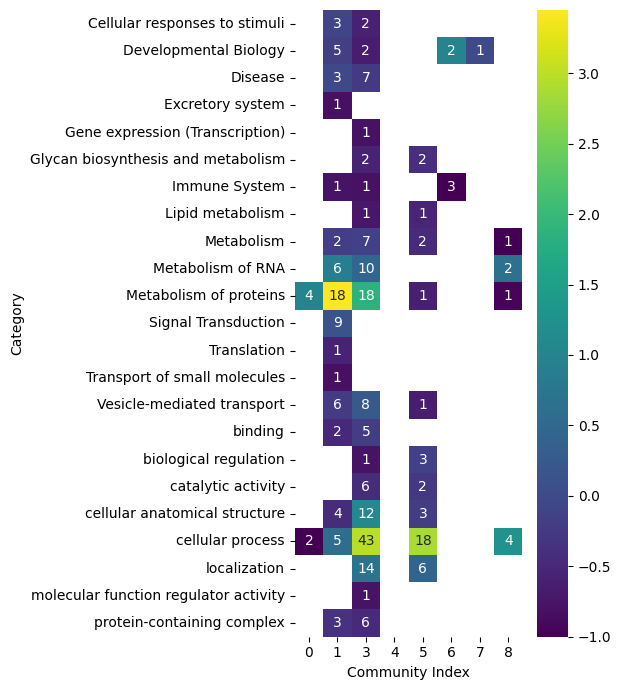

In [287]:
heat_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="fisher_z"
).reindex(columns = idx)

label_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="count"
).reindex(columns = idx)
plt.figure(figsize=(6, 7))
ax = sns.heatmap(
    heat_df,
    cmap="viridis",
    annot=label_df,   # <-- use count for labels
    fmt=".0f",        # integer labels
    cbar=True
)

# ---- WRAP Y-AXIS LABELS ----
MAX_CHARS = 50  # tweak this
wrapped = ["\n".join(textwrap.wrap(str(s), width=MAX_CHARS)) for s in heat_df.index]
ax.set_yticklabels(wrapped, rotation=0)  # keep horizontal

plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/category_gross_overlap_heatmap.png", bbox_inches="tight")
plt.show()
